# Project: Predicting Data Science Salaries (Decision Tree)

## 1. Objective

We will use a **Decision Tree Regressor**, a non-linear model that learns "rules" from the data (e.g., "If Experience is Senior and Location is US, Salary is likely High").

## 2. Methodology
1. **Data Loading:** Load the separate training and testing datasets.
2. **Preprocessing:** Convert categorical text data (e.g., "US", "Senior") into numbers.
3. **Baseline Model:** Train a simple, un-tuned tree to establish a baseline error.
4. **Hyperparameter Tuning:** Use `GridSearchCV` to optimize the tree and prevent overfitting.
5. **Evaluation:** Compare models using RMSE and visualize Feature Importance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load the separate datasets
train_df = pd.read_csv('train_df.csv')
test_df = pd.read_csv('test_df.csv')

print(f"Training Data Shape: {train_df.shape}")
print(f"Testing Data Shape: {test_df.shape}")

# 2. Combine them for consistent preprocessing (The "Sandwich" Method)
train_df['dataset_source'] = 'train'
test_df['dataset_source'] = 'test'
full_df = pd.concat([train_df, test_df], axis=0, ignore_index=True)

Training Data Shape: (41929, 9)
Testing Data Shape: (10483, 9)


## 3. Data Preprocessing

Machine Learning models cannot understand text. We must convert our categorical features into numbers.

### Strategy:
1. **Ordinal Encoding:** For columns with a clear hierarchy (`experience_level`, `company_size`), we map them to ranked numbers (0, 1, 2...).
2. **One-Hot Encoding:** For nominal columns (`job_title`, `company_location`), we create binary "dummy" variables (0 or 1).

In [4]:
# 1. Map Ordinal Features (Ranked)
exp_map = {'EN': 0, 'MI': 1, 'SE': 2, 'EX': 3}
size_map = {'S': 0, 'M': 1, 'L': 2}

full_df['experience_level'] = full_df['experience_level'].map(exp_map)
full_df['company_size'] = full_df['company_size'].map(size_map)

# 2. One-Hot Encode Nominal Features (Unranked)
# We exclude 'dataset_source' and 'salary_in_usd' from encoding
full_df = pd.get_dummies(full_df, columns=['employment_type', 'job_title', 'employee_residence', 'company_location'])

# 3. Split back into X and y
# Separate the sandwich
train_processed = full_df[full_df['dataset_source'] == 'train'].drop('dataset_source', axis=1)
test_processed = full_df[full_df['dataset_source'] == 'test'].drop('dataset_source', axis=1)

# Define Features (X) and Target (y)
y_train = train_processed['salary_in_usd']
X_train = train_processed.drop('salary_in_usd', axis=1)

y_test = test_processed['salary_in_usd']
X_test = test_processed.drop('salary_in_usd', axis=1)

print("Preprocessing Complete!")
print(f"Final Feature Count: {X_train.shape[1]}")

Preprocessing Complete!
Final Feature Count: 440


## 4. Model Training & Hyperparameter Tuning

We will use **GridSearchCV** to find the best parameters for our Decision Tree.
This prevents **overfitting** (memorizing the data) by testing different rules:

* **`max_depth`**: Limits how deep the tree grows.
* **`min_samples_leaf`**: Requires a minimum number of data points in a leaf to make a prediction.

In [5]:
# Define the parameter grid (The "Rules" to test)
param_grid = {
    'max_depth': [None, 10, 20],
    'min_samples_split': [20, 40],
    'min_samples_leaf': [5, 10]
}

# Initialize Grid Search
grid_search = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=param_grid,
    cv=3,          # 3-Fold Cross Validation
    scoring='neg_mean_squared_error',
    n_jobs=1,      # Use 1 core to be safe with RAM
    verbose=1
)

# Train the models
print("Starting Grid Search...")
grid_search.fit(X_train, y_train)

print(f"\nBest Parameters: {grid_search.best_params_}")
best_model = grid_search.best_estimator_

Starting Grid Search...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best Parameters: {'max_depth': None, 'min_samples_leaf': 5, 'min_samples_split': 40}


--- Model Performance ---
Test RMSE: $66,429.39
R² Score:  0.2785


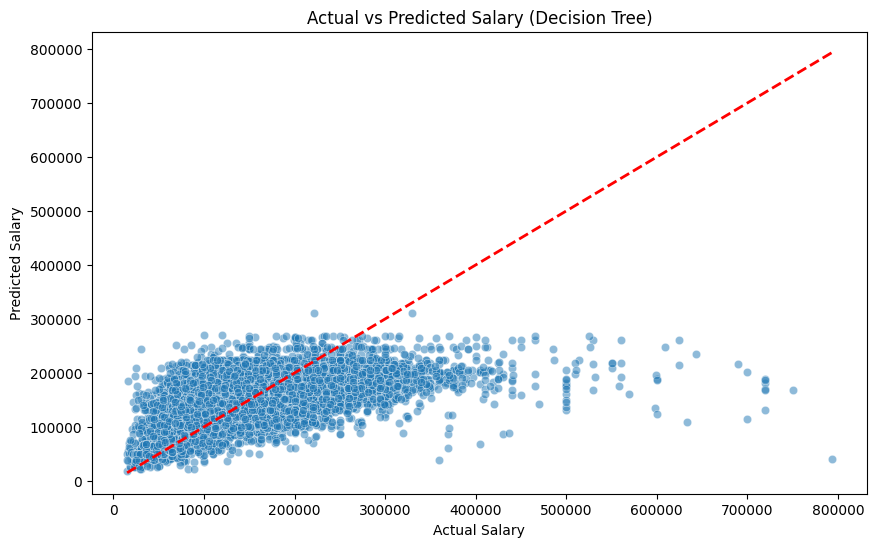

C:\Users\nimit\AppData\Local\Temp\ipykernel_9096\3827406519.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_df, palette='viridis')


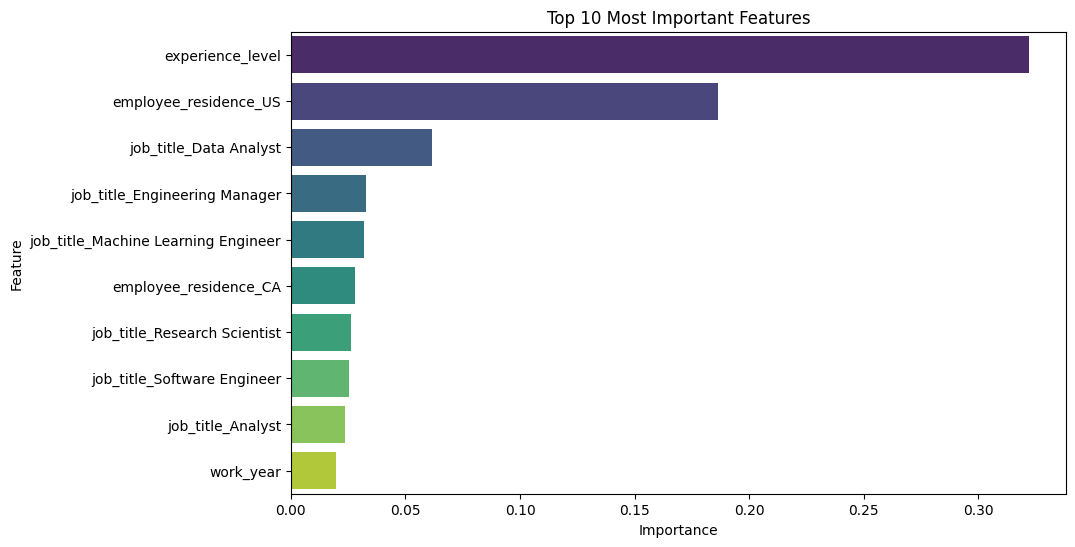

In [6]:
# 1. Make Predictions
preds = best_model.predict(X_test)

# 2. Calculate Metrics
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print("--- Model Performance ---")
print(f"Test RMSE: ${rmse:,.2f}")
print(f"R² Score:  {r2:.4f}")

# --- VISUALIZATION 1: Actual vs Predicted ---
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=preds, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Perfect line
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary (Decision Tree)")
plt.show()

# --- VISUALIZATION 2: Feature Importance ---
# This shows WHICH columns mattered the most
importances = best_model.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for plotting
feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_df = feat_df.sort_values(by='Importance', ascending=False).head(10) # Top 10

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_df, palette='viridis')
plt.title("Top 10 Most Important Features")
plt.show()

## 5. Conclusion

* **Model Performance:** The final Tuned Decision Tree achieved an RMSE of **$66,429**.
* **Key Drivers:** The Feature Importance plot reveals that **Experience Level** and **Location (US)** are the strongest predictors of salary.
* **Visuals:** The Actual vs Predicted plot shows the model follows the general trend but struggles with extreme outliers (very high salaries).